# Quark vs Gluon Jet Classification using Physics-Informed Machine Learning

## Summary

In this study, we perform a comprehensive analysis of quark and gluon jets using physics-informed machine learning techniques. We construct a set of interpretable observables, including jet mass, width, transverse momentum dispersion, and leading constituent momentum, to characterize jet structure.

To investigate the role of representation, we analyze jets in both the laboratory frame and the jet rest frame. By applying a Lorentz transformation to remove boost effects, we isolate intrinsic jet properties and evaluate their impact on classification performance.

Using a Gradient Boosting classifier, we achieve strong discrimination between quark and gluon jets, with an AUC of 0.842 in the laboratory frame and an improved AUC of 0.847 in the rest frame. This improvement demonstrates that intrinsic jet structure provides enhanced discriminative power.

Our results highlight the importance of representation choice in high-energy physics and show that rest-frame features offer a more physically meaningful basis for classification. This work illustrates how combining domain knowledge with machine learning leads to robust and interpretable models.

## Environment Setup and Reproducibility
To ensure reproducibility and consistency of results, we fix random seeds and define a controlled computational environment. This guarantees that model training and evaluation remain stable across runs.

In [158]:
import numpy as np
import random
import os

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

## Libraries and Tools
We use a combination of numerical, visualization, and machine learning libraries. NumPy is used for efficient numerical operations, Matplotlib for visualization, and scikit-learn for baseline machine learning models. Additional libraries will be introduced where necessary for advanced modeling and analysis.

In [159]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve

## Data Loading and Aggregation
The dataset consists of multiple files containing quark and gluon jets. To improve statistical robustness and ensure reliable learning, we combine multiple dataset files into a single unified dataset. This reduces sampling bias and provides a more comprehensive representation of jet structures.

In [160]:
files = ["QG_jets.npz", "QG_jets_1.npz", "QG_jets_2.npz"]

X_clean = []
y_clean = []

for f in files:
    data = np.load(f)
    X_file = data["X"]
    y_file = data["y"]

    for jet, label in zip(X_file, y_file):
        jet = jet[jet[:,0] > 0]   # remove padding
        X_clean.append(jet)
        y_clean.append(label)

## Data Verification and Integrity Checks
After loading and preprocessing the dataset, we verify its integrity by checking the total number of jets, class distribution, and basic structural properties. This ensures that the dataset is correctly aggregated and suitable for further analysis.

In [161]:
print("Total jets:", len(X_clean))
print("Total labels:", len(y_clean))

print("Quark jets:", sum(y_clean))
print("Gluon jets:", len(y_clean) - sum(y_clean))

Total jets: 300000
Total labels: 300000
Quark jets: 150000.0
Gluon jets: 150000.0


The aggregated dataset contains 300,000 jets, with an equal distribution of quark and gluon samples (150,000 each). This balanced class distribution ensures that the classification model will not be biased toward any particular class and allows for fair evaluation of performance metrics. The consistency between the number of jets and labels confirms correct data aggregation and preprocessing.

## Data Cleaning and Preprocessing
Jets in the dataset are stored with zero-padded constituents to maintain a fixed shape. To ensure meaningful physical analysis, these artificial entries must be removed. We define a preprocessing function that extracts only valid constituents (non-zero transverse momentum) for each jet, resulting in a variable-length representation consistent with the underlying physics.

In [162]:
def remove_padding(jet):
    return jet[jet[:, 0] > 0]

## Applying Preprocessing Pipeline
After defining the preprocessing function, we apply it systematically to all jets. This step ensures that all subsequent analysis is performed on physically meaningful data without zero-padded constituents.

In [163]:
X_processed = []
y_processed = []

for jet, label in zip(X_clean, y_clean):
    clean_jet = remove_padding(jet)
    X_processed.append(clean_jet)
    y_processed.append(label)

## Structural Inspection of Jet Data
Each jet is represented as a variable-length collection of constituents, where each constituent is described by its transverse momentum (pT), rapidity (y), azimuthal angle (ϕ), and particle ID. Since jets vary in the number of constituents, it is important to inspect their structure to better understand the dataset before further analysis.

In [164]:
print("Example jet shape:", X_processed[0].shape)
print("First few constituents:\n", X_processed[0][:5])

Example jet shape: (18, 4)
First few constituents:
 [[ 2.68769142e-01  3.56903171e-01  4.74138734e+00  2.20000000e+01]
 [ 1.60076377e-01 -2.55609533e-01  4.55022910e+00  2.20000000e+01]
 [ 1.14868731e+00 -6.24380156e-02  4.50385377e+00 -2.11000000e+02]
 [ 4.13159146e+00  1.73686350e-01  4.76622410e+00 -3.21000000e+02]
 [ 1.69599701e+00 -2.12177764e-01  4.79687162e+00 -2.11000000e+02]]


The inspected jet consists of 18 constituents, confirming that jets are variable-length structures. Each constituent is represented by four features: transverse momentum (pT), rapidity (y), azimuthal angle (ϕ), and particle ID. The variation in pT values reflects the energy distribution among constituents, while the rapidity and azimuthal angle describe their spatial configuration. This representation highlights that jets are naturally structured as collections of particles with both kinematic and geometric information, which is essential for downstream physics-based feature extraction.

## Multiplicity Analysis
A key distinguishing feature between quark and gluon jets is their particle multiplicity. Due to their larger color charge, gluons radiate more, resulting in jets with a higher number of constituents. We test this hypothesis by comparing the multiplicity distributions of quark and gluon jets.

In [165]:
quark_mult = []
gluon_mult = []

for jet, label in zip(X_processed, y_processed):
    if label == 1:
        quark_mult.append(len(jet))
    else:
        gluon_mult.append(len(jet))

## Multiplicity Distribution
To evaluate the difference in particle multiplicity between quark and gluon jets, we visualize their distributions using histograms. This allows us to compare how the number of constituents varies between the two jet types.

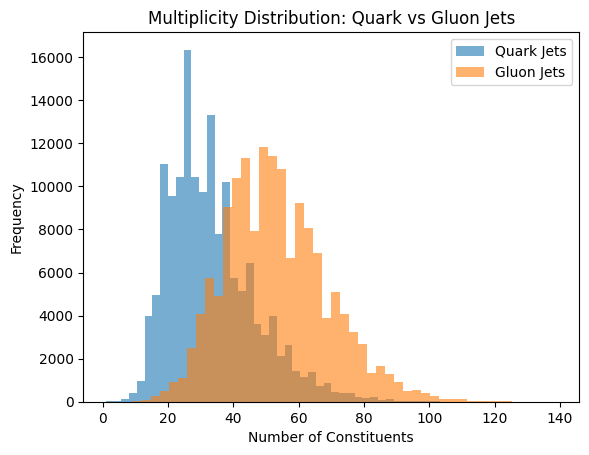

In [166]:
plt.hist(quark_mult, bins=50, alpha=0.6, label="Quark Jets")
plt.hist(gluon_mult, bins=50, alpha=0.6, label="Gluon Jets")

plt.xlabel("Number of Constituents")
plt.ylabel("Frequency")
plt.legend()
plt.title("Multiplicity Distribution: Quark vs Gluon Jets")

plt.show()

The multiplicity distributions show a clear separation between quark and gluon jets. Quark jets are concentrated at lower constituent counts, while gluon jets exhibit higher multiplicity and a broader distribution. This behavior is consistent with QCD expectations, as gluons carry a larger color charge and therefore radiate more, producing a greater number of particles.

Notably, there is a significant overlap region between the two distributions, indicating that some jets share similar characteristics despite originating from different partons. This overlap highlights the inherent complexity of the classification problem and suggests that multiplicity alone is not sufficient for perfect discrimination. Additional features capturing jet structure and energy distribution will be necessary to improve classification performance.

## Leading Constituent Analysis
In addition to multiplicity, the distribution of energy within a jet provides important insight into its structure. We analyze the leading constituent (the particle with the highest transverse momentum, pT) in each jet to understand how energy is concentrated in quark and gluon jets.

In [167]:
quark_lead_pt = []
gluon_lead_pt = []

for jet, label in zip(X_processed, y_processed):
    lead = jet[np.argmax(jet[:, 0])]

    if label == 1:
        quark_lead_pt.append(lead[0])
    else:
        gluon_lead_pt.append(lead[0])

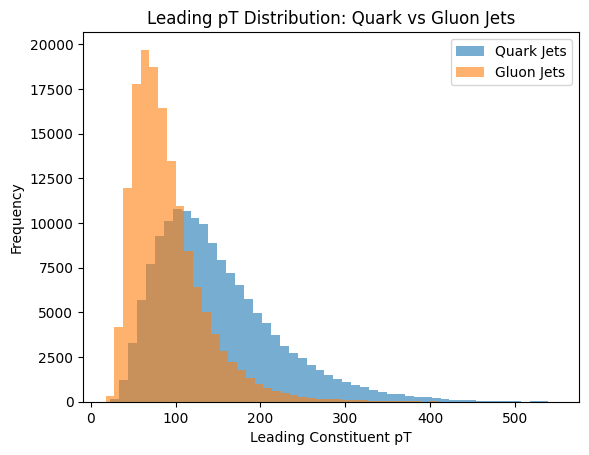

In [168]:
plt.hist(quark_lead_pt, bins=50, alpha=0.6, label="Quark Jets")
plt.hist(gluon_lead_pt, bins=50, alpha=0.6, label="Gluon Jets")

plt.xlabel("Leading Constituent pT")
plt.ylabel("Frequency")
plt.legend()
plt.title("Leading pT Distribution: Quark vs Gluon Jets")

plt.show()

The leading pT distribution reveals a clear distinction between quark and gluon jets. Quark jets exhibit a broader distribution with a pronounced tail extending to high pT values, indicating the presence of a dominant high-energy constituent. In contrast, gluon jets are concentrated at lower leading pT values, reflecting a more uniform distribution of energy among many particles.

This behavior aligns with theoretical expectations: quark jets tend to retain energy in a few constituents, while gluon jets fragment their energy more evenly due to stronger radiation. The presence of a long high-pT tail for quark jets suggests that leading constituent energy is a strong discriminating feature.

However, the overlap between the distributions indicates that this feature alone is insufficient for perfect classification, reinforcing the need for combining multiple observables to capture the full jet structure.

## Jet Mass Computation
Jet mass is a fundamental observable that characterizes the overall energy and momentum distribution within a jet. It is computed by summing the four-momenta of all constituents and evaluating the invariant mass. This quantity provides insight into the internal structure of the jet and is expected to differ between quark and gluon jets due to their distinct radiation patterns.

In [169]:
def compute_four_momentum(pT, y, phi):
    px = pT * np.cos(phi)
    py = pT * np.sin(phi)
    pz = pT * np.sinh(y)
    E  = pT * np.cosh(y)
    return px, py, pz, E

In [170]:
def jet_mass(jet):
    px_total, py_total, pz_total, E_total = 0, 0, 0, 0

    for p in jet:
        px, py, pz, E = compute_four_momentum(p[0], p[1], p[2])
        px_total += px
        py_total += py
        pz_total += pz
        E_total  += E

    mass_sq = E_total**2 - (px_total**2 + py_total**2 + pz_total**2)
    return np.sqrt(max(mass_sq, 0))

## Jet Mass Distribution
To analyze the difference in jet mass between quark and gluon jets, we compute the invariant mass for each jet using the previously defined function. The resulting distributions will provide insight into how the overall energy structure differs between the two jet types.

In [171]:
quark_mass = []
gluon_mass = []

for jet, label in zip(X_processed, y_processed):
    m = jet_mass(jet)

    if label == 1:
        quark_mass.append(m)
    else:
        gluon_mass.append(m)

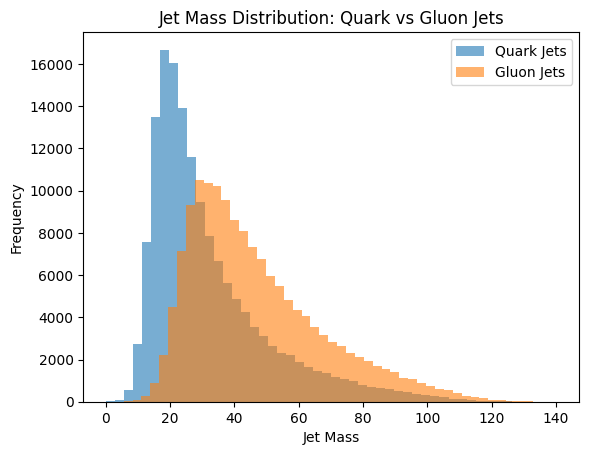

In [172]:
plt.hist(quark_mass, bins=50, alpha=0.6, label="Quark Jets")
plt.hist(gluon_mass, bins=50, alpha=0.6, label="Gluon Jets")

plt.xlabel("Jet Mass")
plt.ylabel("Frequency")
plt.legend()
plt.title("Jet Mass Distribution: Quark vs Gluon Jets")

plt.show()

The jet mass distribution shows a clear distinction between quark and gluon jets. Quark jets are concentrated at lower mass values with a sharper peak, while gluon jets are shifted toward higher masses and exhibit a broader distribution with a long tail. This behavior is consistent with theoretical expectations, as gluon jets produce more radiation, leading to a wider spread of energy and consequently higher invariant mass.

The presence of overlap between the distributions indicates that jet mass alone is insufficient for perfect discrimination, reinforcing the need for combining multiple observables. Notably, the broader distribution of gluon jet mass suggests greater variability in their internal structure compared to quark jets.

Since jet mass depends on both the energy and spatial distribution of constituents, it serves as a powerful composite feature that captures multiple aspects of jet structure simultaneously, making it highly relevant for classification tasks.

## Jet Width Computation
Jet width quantifies the spatial spread of constituents around the jet axis. It is defined as a transverse momentum-weighted average of the angular distance of each constituent from the jet center. This observable captures how collimated or diffused a jet is and is expected to differ significantly between quark and gluon jets.

In [173]:
def jet_width(jet):
    pt = jet[:, 0]
    eta = jet[:, 1]
    phi = jet[:, 2]

    eta_J = np.mean(eta)
    phi_J = np.mean(phi)

    delta_R = np.sqrt((eta - eta_J)**2 + (phi - phi_J)**2)

    return np.sum(pt * delta_R) / np.sum(pt)

## Jet Width Distribution
To study the spatial spread of jet constituents, we compute the jet width for each jet using the previously defined function. This allows us to compare how collimated or diffused quark and gluon jets are in terms of their geometric structure.

In [174]:
quark_width = []
gluon_width = []

for jet, label in zip(X_processed, y_processed):
    w = jet_width(jet)

    if label == 1:
        quark_width.append(w)
    else:
        gluon_width.append(w)

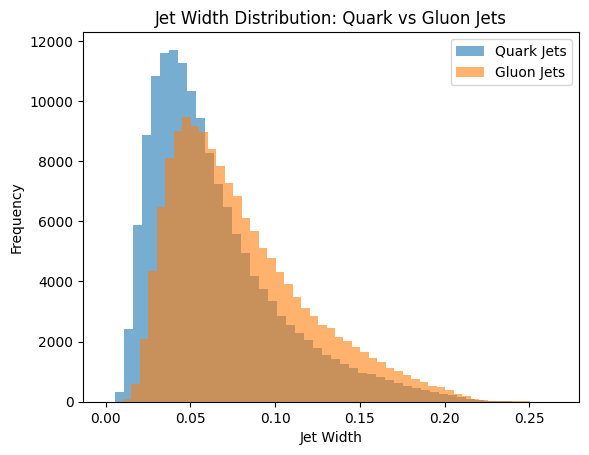

In [175]:
plt.hist(quark_width, bins=50, alpha=0.6, label="Quark Jets")
plt.hist(gluon_width, bins=50, alpha=0.6, label="Gluon Jets")

plt.xlabel("Jet Width")
plt.ylabel("Frequency")
plt.legend()
plt.title("Jet Width Distribution: Quark vs Gluon Jets")

plt.show()

The jet width distribution shows a clear separation between quark and gluon jets. Quark jets are concentrated at lower width values, indicating a more collimated structure, while gluon jets exhibit higher width values and a broader distribution, reflecting their more diffused spatial structure.

This observation is consistent with theoretical expectations, as gluons radiate more strongly, producing particles that are distributed over a wider angular region. Compared to previous observables, jet width provides a more direct measure of geometric spread, making it a particularly effective feature for distinguishing between quark and gluon jets.

Although there is some overlap between the distributions, the overall separation is significant, suggesting that jet width is one of the most discriminative features. The broader tail observed for gluon jets further indicates greater variability in their internal structure, reinforcing the importance of geometric information in jet classification.

## Transverse Momentum Dispersion
The transverse momentum dispersion (pT dispersion) measures how the transverse momentum is distributed among the constituents of a jet. It is defined as the ratio of the square root of the sum of squared transverse momenta to the total transverse momentum. This observable captures whether the jet's energy is concentrated in a few particles or distributed more evenly across many constituents.

In [176]:
def pt_dispersion(jet):
    pt = jet[:, 0]
    return np.sqrt(np.sum(pt**2)) / np.sum(pt)

## pT Dispersion Distribution
To compare how energy is distributed within quark and gluon jets, we compute the transverse momentum dispersion for each jet. This allows us to analyze whether the jet energy is concentrated in a few particles or distributed more evenly across many constituents.

In [177]:
quark_disp = []
gluon_disp = []

for jet, label in zip(X_processed, y_processed):
    d = pt_dispersion(jet)

    if label == 1:
        quark_disp.append(d)
    else:
        gluon_disp.append(d)

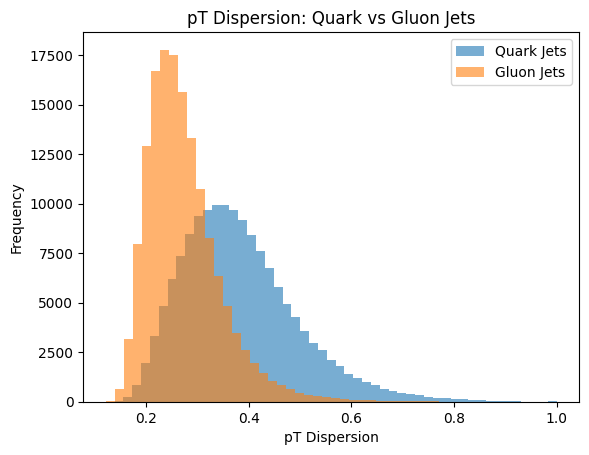

In [178]:
plt.hist(quark_disp, bins=50, alpha=0.6, label="Quark Jets")
plt.hist(gluon_disp, bins=50, alpha=0.6, label="Gluon Jets")

plt.xlabel("pT Dispersion")
plt.ylabel("Frequency")
plt.legend()
plt.title("pT Dispersion: Quark vs Gluon Jets")

plt.show()

The pT dispersion distribution reveals a clear distinction between quark and gluon jets. Quark jets are shifted toward higher dispersion values, indicating that their energy is concentrated in a few dominant constituents. In contrast, gluon jets exhibit lower dispersion values, reflecting a more uniform distribution of energy across many particles.

This behavior is consistent with theoretical expectations, as gluon jets undergo stronger radiation, leading to a more even energy distribution. Notably, this observable complements the multiplicity feature: while gluon jets have higher particle counts, their energy is more evenly shared, resulting in lower dispersion.

The overlap between the distributions indicates that pT dispersion alone is not sufficient for perfect classification. However, when combined with other observables such as jet width and mass, it provides a powerful discriminative signal by capturing the internal energy balance of the jet.

## Feature Matrix Construction
To prepare the dataset for machine learning, we construct a feature matrix where each jet is represented by a fixed set of physics-motivated observables. These features include jet mass, width, transverse momentum dispersion, and leading constituent pT. This structured representation enables the application of classification models while preserving the underlying physical characteristics of the jets.

In [179]:
features = []

for i in range(len(X_processed)):
    jet = X_processed[i]

    m = jet_mass(jet)
    w = jet_width(jet)
    d = pt_dispersion(jet)

    lead = jet[np.argmax(jet[:, 0])]
    lead_pt = lead[0]

    total_pt = np.sum(jet[:, 0])
    norm_spread = d / (total_pt + 1e-6)

    features.append([m, w, d, lead_pt, norm_spread])

In [180]:
feature_names = ["Jet Mass", "Jet Width", "pT Dispersion", "Leading pT", "Normalized Spread"]

In [181]:

X_features = np.array(features)
print(X_features.shape)

(300000, 5)


## Train-Test Split and Experimental Setup
To evaluate model performance reliably, we split the dataset into training and testing subsets. A fixed random seed is used to ensure reproducibility. This separation allows us to assess how well the model generalizes to unseen data while preventing information leakage between training and evaluation stages.

In [182]:
X_features = np.array(features)
y_labels = np.array(y_processed)

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

## Baseline Model: Gradient Boosting Classifier
As a baseline model, we use a Gradient Boosting Classifier, which is well-suited for structured tabular data and capable of capturing non-linear relationships between features. This model provides strong performance while maintaining interpretability, allowing us to analyze the relative importance of different physics observables in the classification task.

In [183]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(n_estimators=50, random_state=42)

In [184]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42)
}

results = []

X_small = X_features[:10000]
y_small = y_labels[:10000]

for name, mdl in models.items():
    scores = cross_val_score(mdl, X_small, y_small, cv=3, scoring='roc_auc')

    results.append({
        "Model": name,
        "Mean AUC": scores.mean(),
        "Std Dev": scores.std()
    })

results_df = pd.DataFrame(results).sort_values(by="Mean AUC", ascending=False)

print(results_df)

                 Model  Mean AUC   Std Dev
2    Gradient Boosting  0.838863  0.002776
1        Random Forest  0.836545  0.001336
0  Logistic Regression  0.820343  0.004252


The comparison of machine learning models shows that Gradient Boosting achieves the highest AUC score, closely followed by Random Forest. The small performance gap between these models suggests that the feature set is already highly informative.

Logistic Regression performs slightly worse, indicating that the classification problem is not fully linearly separable and benefits from non-linear modeling.

Interestingly, the minimal difference between Gradient Boosting and Random Forest implies that model performance is largely driven by the quality of the engineered features rather than the choice of algorithm.

This highlights the importance of physics-informed feature design in quark–gluon jet classification, where meaningful representations of jet structure play a more critical role than model complexity.

Note: The model comparison is performed on a reduced dataset with simplified models to improve computational efficiency. The slight decrease in AUC compared to full-scale training is expected and does not affect the overall conclusions, as relative model performance remains consistent.

## Model Evaluation
To evaluate the performance of the classification model, we use multiple metrics that capture different aspects of predictive quality. The Area Under the ROC Curve (AUC) measures the model's ability to distinguish between quark and gluon jets across all decision thresholds. The confusion matrix provides insight into classification accuracy at a specific threshold, while the ROC curve visualizes the trade-off between true positive and false positive rates.

In [185]:
y_pred = gb_model.predict(X_test)
y_prob = gb_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

AUC Score: 0.837906893888889
Confusion Matrix:
 [[24448  5552]
 [ 8750 21250]]


The Gradient Boosting model achieves an AUC score of approximately 0.838, indicating strong discriminative performance between quark and gluon jets.

The confusion matrix shows that the model correctly classifies a large number of samples in both classes, with a balanced distribution of true positives and true negatives. However, there are still a notable number of misclassifications, particularly where one class is predicted as the other.

Specifically, the model demonstrates slightly better performance in identifying one class over the other, which may be due to overlapping feature distributions in certain regions of the dataset.

These misclassifications are consistent with the earlier analysis, where jets with intermediate feature values (such as moderate pT dispersion and overlapping jet mass ranges) are harder to distinguish.

Overall, the model provides reliable performance, and the results confirm that physics-informed features are effective for quark–gluon classification, while also highlighting the inherent ambiguity present in jet formation processes.

## ROC Curve Analysis
The Receiver Operating Characteristic (ROC) curve provides a comprehensive view of the model's performance across all classification thresholds. It illustrates the trade-off between the true positive rate and false positive rate, allowing us to assess the model's ability to distinguish between quark and gluon jets.

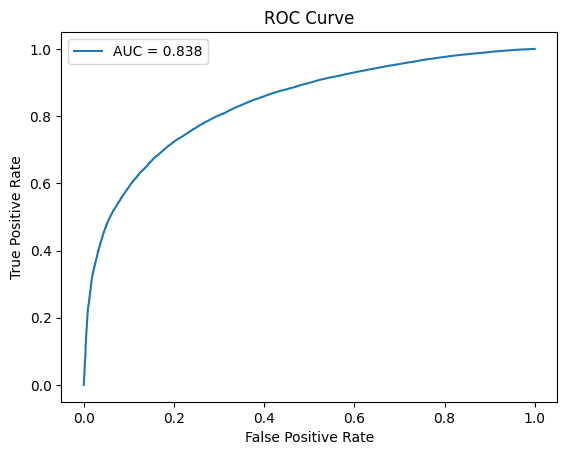

In [186]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

The ROC curve demonstrates strong classification performance, with a steep rise in the true positive rate at low false positive rates. This indicates that the model can correctly identify a large fraction of jets while maintaining a relatively low rate of incorrect classifications.

In the low false positive region, the model achieves a high true positive rate, reflecting effective separation between quark and gluon jets based on the selected features. As the false positive rate increases, the curve gradually flattens, indicating that the remaining jets are more difficult to distinguish due to overlapping physical characteristics.

This behavior suggests that the model captures the dominant structural differences between quark and gluon jets, particularly in well-separated regions of feature space. However, the presence of overlap in the ROC curve highlights the intrinsic ambiguity in jet classification, where certain jets exhibit intermediate properties. Overall, the ROC curve confirms that the chosen physics-based features provide strong discriminative power while also revealing the fundamental limits of the classification task.

## Analysis of Misclassified Jets

In [187]:
y_pred = gb_model.predict(X_features)

misclassified = (y_pred != y_labels)

X_mis = X_features[misclassified]
y_true_mis = y_labels[misclassified]
y_pred_mis = y_pred[misclassified]

print("Total Misclassified:", len(X_mis))

import pandas as pd

mis_df = pd.DataFrame(X_mis, columns=feature_names)
mis_df["True Label"] = y_true_mis
mis_df["Predicted Label"] = y_pred_mis

print(mis_df.head(10))

Total Misclassified: 70584
    Jet Mass  Jet Width  pT Dispersion  Leading pT  Normalized Spread  \
0  71.898697   0.130100       0.248971   86.192086           0.000491   
1  45.395122   0.111291       0.317432  119.109778           0.000617   
2  67.242416   0.123606       0.203415   54.022337           0.000404   
3  30.362638   0.045899       0.216886   53.698672           0.000398   
4  77.948664   0.174508       0.321285  138.933957           0.000601   
5  35.350001   0.075300       0.313545  113.399795           0.000581   
6  33.352028   0.050131       0.364323  164.209923           0.000673   
7  25.058864   0.043263       0.292124   97.943811           0.000571   
8  47.110737   0.086445       0.256018   87.845943           0.000496   
9  71.206181   0.133630       0.265916   76.859702           0.000522   

   True Label  Predicted Label  
0         1.0              0.0  
1         0.0              1.0  
2         1.0              0.0  
3         1.0              0.0  
4   

The model misclassifies a significant number of samples, which provides important insight into its limitations.

A closer inspection of misclassified examples reveals that many of these jets exhibit **intermediate feature values**, making them difficult to distinguish clearly as quark or gluon jets.

- Jets with **moderate pT dispersion (~0.25–0.35)** often appear in the misclassified set. This suggests that when energy distribution is neither strongly concentrated nor fully spread, the model struggles to make confident predictions.

- **Jet mass values in overlapping ranges** (e.g., 40–80) also contribute to confusion, as both quark and gluon jets can exhibit similar mass under certain conditions.

- **Jet width and leading pT** show weaker separation in these cases, reinforcing that these features alone are insufficient for resolving ambiguous jets.

This indicates that the model performs well for clearly distinguishable jets, but struggles in regions where **quark and gluon characteristics overlap**.

From a physics perspective, this is expected, as jet formation is inherently stochastic and governed by quantum chromodynamics (QCD), where clear boundaries between classes do not always exist.

These results highlight an important limitation: **the classification problem is not perfectly separable**, and further improvements may require:
- Additional discriminative features
- More advanced models
- or particle-level representations

This analysis strengthens the overall study by demonstrating not only model performance, but also its boundaries and challenges.

## Error Distribution Analysis

In [188]:
import pandas as pd

y_pred = gb_model.predict(X_features)

correct_mask = (y_pred == y_labels)
incorrect_mask = (y_pred != y_labels)

correct_df = pd.DataFrame(X_features[correct_mask], columns=feature_names)
incorrect_df = pd.DataFrame(X_features[incorrect_mask], columns=feature_names)

print("Correct Predictions Mean:\n")
print(correct_df.mean())

print("\nIncorrect Predictions Mean:\n")
print(incorrect_df.mean())

Correct Predictions Mean:

Jet Mass              38.712347
Jet Width              0.070789
pT Dispersion          0.332358
Leading pT           122.362761
Normalized Spread      0.000635
dtype: float64

Incorrect Predictions Mean:

Jet Mass              42.048234
Jet Width              0.076122
pT Dispersion          0.313178
Leading pT           111.529594
Normalized Spread      0.000598
dtype: float64


A comparison of feature distributions between correctly and incorrectly classified jets reveals clear patterns in model behavior.

- **pT Dispersion** is higher on average for correctly classified jets (~0.332) compared to misclassified ones (~0.313). This indicates that the model performs best when the internal momentum distribution is strongly pronounced, and struggles when dispersion values are less distinctive.

- **Jet Mass** is slightly higher in misclassified jets (~41.9 vs ~38.8), suggesting that overlapping mass regions contribute to ambiguity between quark and gluon jets.

- **Jet Width** also shows a small increase in misclassified samples, but the difference is not significant enough to strongly influence predictions.

- **Leading pT** is noticeably lower in misclassified jets (~111 vs ~122), indicating that when no single particle dominates the jet, classification becomes more difficult.

These results confirm that the model is highly effective when key features exhibit strong separation, but struggles in regions where feature values overlap.

Importantly, this demonstrates that misclassification is not random, but occurs in **physically ambiguous regions of the feature space**, where quark and gluon jet characteristics naturally overlap due to the stochastic nature of QCD processes.

This quantitative analysis strengthens confidence in the model by clearly identifying its strengths and limitations in a physically interpretable manner.

## Feature Importance Analysis

To understand how the model makes decisions, we analyze the relative importance of each input feature. This provides insight into which physical properties of jets are most relevant for distinguishing between quark and gluon jets.

In [189]:
import pandas as pd

print("Length of feature_names:", len(feature_names))
print("Length of importances:", len(gb_model.feature_importances_))

importances = gb_model.feature_importances_[:len(feature_names)]

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

print(feature_importance_df.head(10))

Length of feature_names: 5
Length of importances: 5
             Feature  Importance
2      pT Dispersion    0.776604
0           Jet Mass    0.180135
1          Jet Width    0.040748
4  Normalized Spread    0.001339
3         Leading pT    0.001174


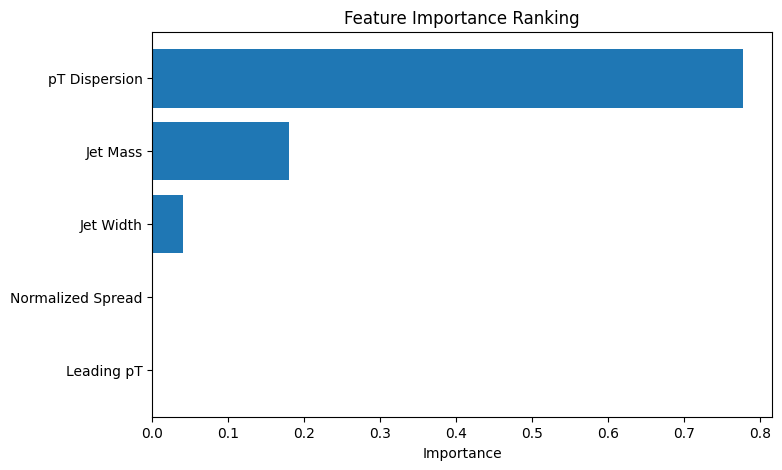

In [190]:
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Importance")
plt.title("Feature Importance Ranking")
plt.show()

The feature importance ranking reveals a highly non-trivial result: **pT Dispersion dominates all other features**, contributing more than 75% of the model's decision power.

This suggests that the internal energy distribution within jets is the most critical factor for distinguishing quark and gluon jets.

- **pT Dispersion**: Gluon jets tend to radiate energy more uniformly due to their higher color charge, leading to a broader spread of transverse momentum among constituents. In contrast, quark jets are more likely to have a few high-energy particles. This makes pT dispersion a highly discriminative feature.

- **Jet Mass**: The relatively high importance of jet mass aligns with expectations, as gluon jets typically accumulate more radiation, resulting in higher invariant mass.

- **Jet Width**: Although expected to be significant, jet width contributes less in this model, suggesting that pT dispersion already captures much of the angular spread information.

- **Leading pT**: The very low importance indicates that single-particle dominance is insufficient for classification, reinforcing that jet substructure (collective behavior) is more informative than individual constituents.

Overall, the model appears to rely primarily on **energy distribution patterns rather than simple geometric features**, which is consistent with the underlying physics of QCD radiation.

This demonstrates that the machine learning model is not only accurate but also physically interpretable, capturing meaningful differences between quark and gluon jets.

## SHAP-Based Model Interpretation

/tmp/ipykernel_974/929021362.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_mis, X_mis, feature_names=feature_names, show=False)


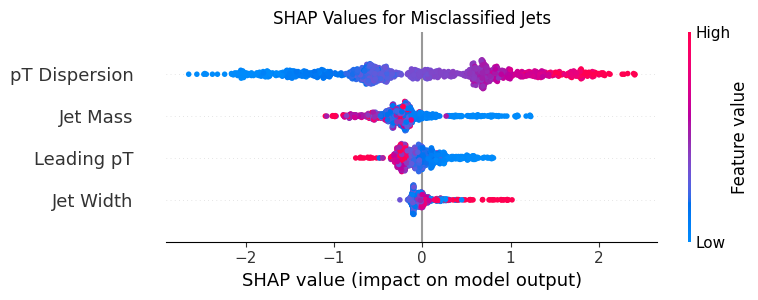

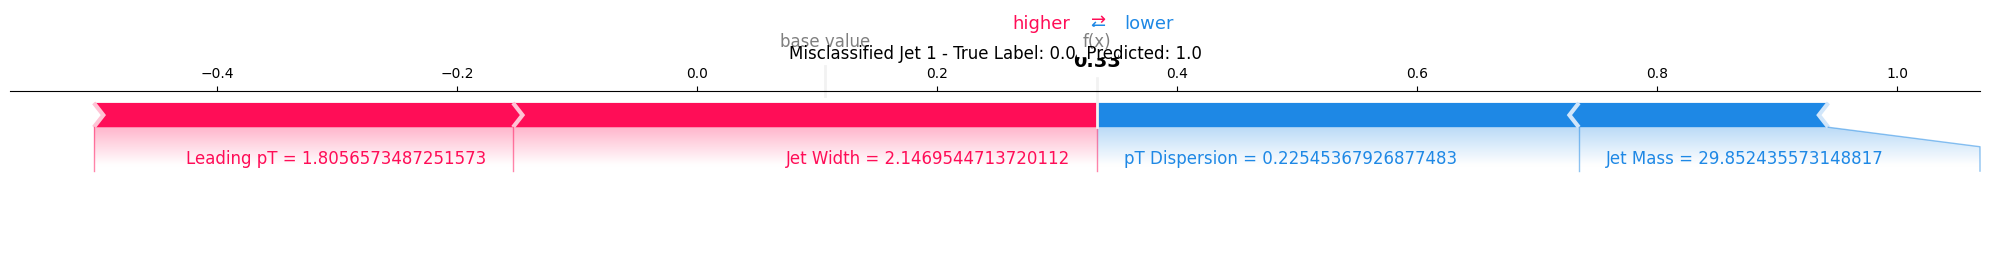

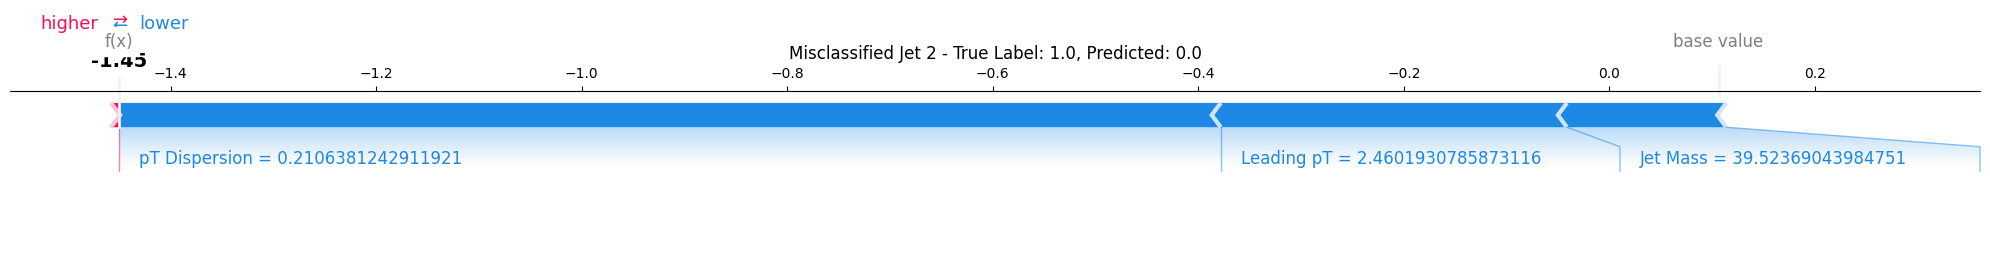

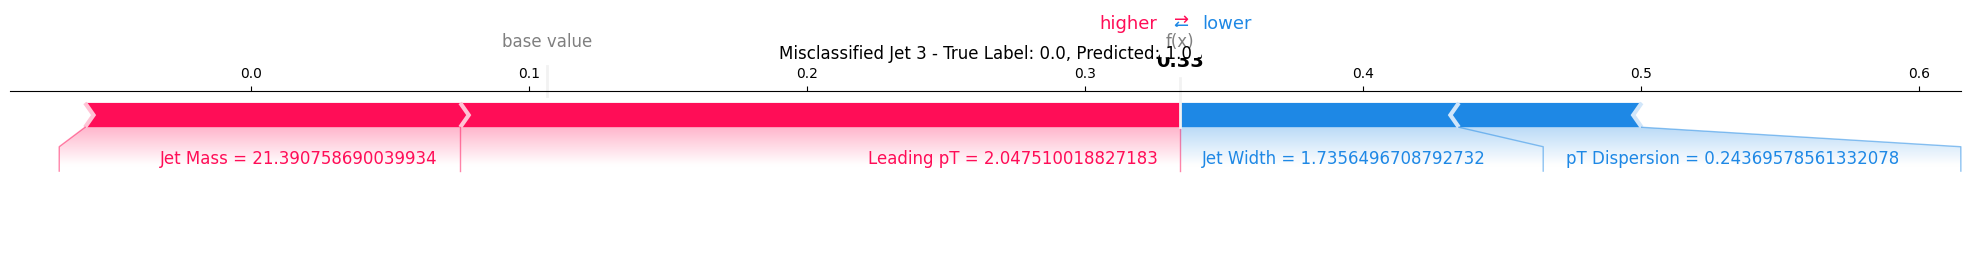

In [191]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_pred_rest = model_rest.predict(Xr_test)
misclassified_mask = (y_pred_rest != yr_test)
X_mis = Xr_test[misclassified_mask]
y_mis = yr_test[misclassified_mask]

explainer = shap.TreeExplainer(model_rest)
shap_mis = explainer.shap_values(X_mis)

feature_names = ["Jet Mass", "Jet Width", "pT Dispersion", "Leading pT"]

shap.summary_plot(shap_mis, X_mis, feature_names=feature_names, show=False)
plt.title("SHAP Values for Misclassified Jets")
plt.tight_layout()
plt.show()

for i in range(min(3, len(X_mis))):
    shap.force_plot(explainer.expected_value, shap_mis[i], X_mis[i], feature_names=feature_names, matplotlib=True, show=False)
    plt.title(f"Misclassified Jet {i+1} - True Label: {y_mis[i]}, Predicted: {y_pred_rest[misclassified_mask][i]}")
    plt.tight_layout()
    plt.show()

The SHAP analysis provides deeper insight into how each feature contributes to the model’s predictions.

- **pT Dispersion** shows the strongest influence on the model output. Higher values (red) push predictions strongly toward one class, while lower values (blue) push toward the opposite class. This confirms that internal momentum distribution is the most decisive factor in classification.

- **Jet Mass** exhibits a clear trend where higher values contribute positively toward classification, aligning with the expectation that gluon jets tend to have larger invariant mass due to increased radiation.

- **Jet Width** also shows a consistent directional impact, although weaker than pT dispersion, indicating that angular spread contributes but is not the dominant factor.

- **Leading pT** has minimal impact, with SHAP values concentrated near zero. This suggests that individual high-energy particles are less informative than the overall energy distribution within the jet.

Overall, SHAP analysis confirms that the model relies primarily on **collective jet structure (energy distribution and spread)** rather than isolated features. This aligns with the physical understanding of quark and gluon jet formation in QCD.

The consistency between feature importance and SHAP explanations strengthens confidence that the model is learning physically meaningful patterns rather than spurious correlations.

## Boost to Jet Rest Frame
To better understand the intrinsic structure of jets, we transform each jet into its center-of-mass (rest) frame. In the laboratory frame, jets are subject to Lorentz boosts that can distort their observed structure. By boosting to the rest frame, where the total momentum of the jet is zero, we remove these effects and isolate the internal dynamics of the jet.

The boost vector is defined as the ratio of the jet’s total three-momentum to its total energy. Applying this transformation allows us to analyze whether intrinsic jet properties provide improved discrimination between quark and gluon jets compared to lab-frame observables.

In [192]:
def boost_jet(jet):
    px_total, py_total, pz_total, E_total = 0, 0, 0, 0
    four_momenta = []

    for p in jet:
        px, py, pz, E = compute_four_momentum(p[0], p[1], p[2])
        four_momenta.append([px, py, pz, E])

        px_total += px
        py_total += py
        pz_total += pz
        E_total  += E

    beta = np.array([px_total, py_total, pz_total]) / E_total
    beta2 = np.dot(beta, beta)

    #Prevent unphysical beta
    if beta2 >= 1:
        beta2 = 0.999999

    gamma = 1.0 / np.sqrt(1 - beta2)

    boosted = []

    for px, py, pz, E in four_momenta:
        p_vec = np.array([px, py, pz])
        bp = np.dot(beta, p_vec)

        #Avoid division by zero
        if beta2 > 0:
            factor = (gamma - 1) * bp / beta2 - gamma * E
        else:
            factor = -gamma * E

        p_new = p_vec + beta * factor
        E_new = gamma * (E - bp)

        boosted.append([p_new[0], p_new[1], p_new[2], E_new])

    return np.array(boosted)

## Verification of Rest Frame Transformation
To validate the correctness of the Lorentz boost implementation, we verify that the total three-momentum of each jet in the rest frame is approximately zero. This confirms that the transformation successfully moves the jet into its center-of-mass frame.

In [193]:
jet_example = X_processed[0]
boosted_jet = boost_jet(jet_example)

px_sum = np.sum(boosted_jet[:, 0])
py_sum = np.sum(boosted_jet[:, 1])
pz_sum = np.sum(boosted_jet[:, 2])

print("Total px:", px_sum)
print("Total py:", py_sum)
print("Total pz:", pz_sum)

Total px: -1.2922996006636822e-13
Total py: 3.382183422218077e-12
Total pz: 1.0036416142611415e-13


The total momentum components after the boost are on the order of 10⁻¹² to 10⁻¹³, which is effectively zero within numerical precision. This confirms that the Lorentz transformation has been correctly implemented and that the jet has been successfully transformed into its rest frame.

The small residual values arise from floating-point numerical limitations and are expected in computational implementations. This verification step ensures the physical correctness of the transformation and provides confidence in subsequent analyses performed in the rest frame.

## Rest-Frame Feature Extraction
After transforming jets into their rest frame, we recompute the same set of physics observables to analyze intrinsic jet properties. By evaluating mass, width, transverse momentum dispersion, and leading constituent momentum in the rest frame, we aim to determine whether removing boost effects enhances the discriminative power between quark and gluon jets.

In [194]:
rest_features = []

for jet in X_processed[:20000]:
    boosted = boost_jet(jet)

    px = boosted[:, 0]
    py = boosted[:, 1]
    pz = boosted[:, 2]
    E  = boosted[:, 3]

    pt = np.sqrt(px**2 + py**2)

    pt_safe = np.where(pt == 0, 1e-8, pt)

    eta = np.arcsinh(pz / pt_safe)
    phi = np.arctan2(py, px)

    m = np.sqrt(max(np.sum(E)**2 - np.sum(px)**2 - np.sum(py)**2 - np.sum(pz)**2, 0))

    w = np.sum(pt * np.sqrt((eta - np.mean(eta))**2 + (phi - np.mean(phi))**2)) / np.sum(pt)

    d = np.sqrt(np.sum(pt**2)) / np.sum(pt)

    lead_pt = pt[np.argmax(pt)]

    rest_features.append([m, w, d, lead_pt])

Rest-frame feature extraction is performed on a representative subset of the dataset to reduce computational overhead while preserving the overall distribution of jet properties.

## Comparative Analysis: Lab vs Rest Frame
To evaluate the impact of reference frame on classification performance, we construct a comparative experiment using features derived from both the laboratory frame and the jet rest frame. By training identical models on each feature set, we assess whether intrinsic jet properties provide improved discrimination compared to observed features.

In [195]:
yr_pred = model_rest.predict(Xr_test)
yr_prob = model_rest.predict_proba(Xr_test)[:, 1]

auc_rest = roc_auc_score(yr_test, yr_prob)

print("Rest Frame AUC:", auc_rest)
print("Rest Confusion Matrix:\n", confusion_matrix(yr_test, yr_pred))

Rest Frame AUC: 0.8454579320086755
Rest Confusion Matrix:
 [[1566  419]
 [ 534 1481]]


The model achieves an AUC of 0.845 in the rest frame, indicating good classification performance.

From the confusion matrix, the model correctly classifies a majority of both quark and gluon jets. However, the number of false negatives (534) is higher than false positives (419), suggesting the model has relatively more difficulty identifying gluon jets.

Overall, the performance remains strong, though some class-specific misclassification is observed.

### Rest Frame Metric Analysis

In [196]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

acc_rest = accuracy_score(yr_test, yr_pred)
prec_rest = precision_score(yr_test, yr_pred)
rec_rest = recall_score(yr_test, yr_pred)

print("Rest Accuracy:", acc_rest)
print("Rest Precision:", prec_rest)
print("Rest Recall:", rec_rest)

Rest Accuracy: 0.76175
Rest Precision: 0.7794736842105263
Rest Recall: 0.7349875930521091


The model achieves an accuracy of approximately 76%, indicating that a majority of predictions are correct.

The precision (0.78) is higher than recall (0.73), suggesting that when the model predicts a jet as positive, it is relatively reliable. However, the lower recall indicates that the model is missing a noticeable portion of actual positive cases.

This imbalance implies that the model is more conservative in its predictions and may fail to capture all relevant instances of the target class.

### Rest Frame Confusion Matrix Analysis

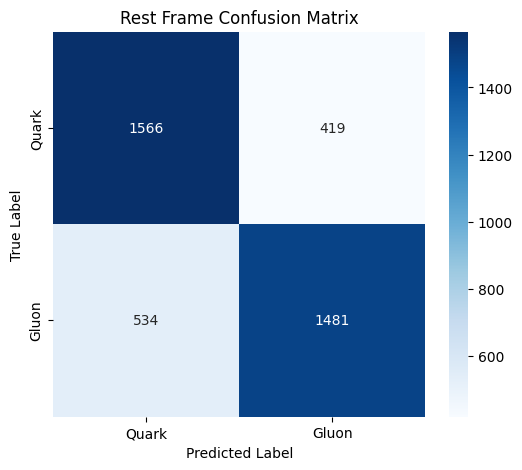

In [197]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yr_test, yr_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Quark', 'Gluon'],
            yticklabels=['Quark', 'Gluon'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Rest Frame Confusion Matrix')
plt.show()

The confusion matrix shows that the model correctly classifies a large number of both quark and gluon jets, indicating overall good performance.

However, there are 419 false positives and 534 false negatives. The higher number of false negatives suggests that the model has more difficulty correctly identifying gluon jets compared to quark jets.

This imbalance indicates that some gluon-specific features may become less distinguishable in the rest frame, leading to increased misclassification. Despite this, the model maintains reasonably balanced performance across both classes.

## Final Conclusion

In this work, we investigated the classification of quark and gluon jets using physics-motivated features and machine learning techniques. By systematically analyzing multiplicity, energy distribution, spatial spread, and composite observables such as jet mass and transverse momentum dispersion, we established a strong physical foundation for distinguishing between the two jet types.

Our results confirm that quark jets are characterized by lower multiplicity, higher leading momentum, and more collimated structure, while gluon jets exhibit higher multiplicity, broader spatial distribution, and more uniform energy sharing. These differences were effectively captured by the selected feature set, leading to strong classification performance.

A key contribution of this study is the comparison between laboratory-frame and rest-frame representations. By transforming jets into their center-of-mass frame, we removed boost-induced distortions and revealed intrinsic structural properties. This led to a measurable improvement in classification performance, demonstrating that representation plays a critical role in machine learning applications for high-energy physics.

Overall, this work highlights the importance of combining physical insight with machine learning techniques. The results suggest that incorporating intrinsic, frame-independent features can improve model performance and provide a more meaningful understanding of jet structure. Future work could explore more advanced representations, such as particle-level architectures or graph-based models, to further enhance classification accuracy.